In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from statsmodels.tsa.seasonal import STL

In [3]:
taxi_df = pd.read_csv('Data/NAB/data/realKnownCause/nyc_taxi.csv')
ambient_temp_df = pd.read_csv('Data/NAB/data/realKnownCause/ambient_temperature_system_failure.csv')
cpu_df = pd.read_csv('Data/NAB/data/realKnownCause/cpu_utilization_asg_misconfiguration.csv')

In [4]:
#добавим labels
with open('Data/NAB/labels/combined_labels.json') as f:
    labels = json.load(f)

labels['realKnownCause/nyc_taxi.csv'].append(taxi_df['timestamp'].iloc[-1])

taxi_df['anomaly'] = 0

for i in range(0, len(labels['realKnownCause/nyc_taxi.csv']) - 1, 2):
    start = labels['realKnownCause/nyc_taxi.csv'][i]
    end = labels['realKnownCause/nyc_taxi.csv'][i+1]

    mask = ((taxi_df['timestamp'] <= end) & (taxi_df['timestamp'] >= start))
    taxi_df.loc[mask, 'anomaly'] = 1
    

ambient_temp_df['anomaly'] = 0

for i in range(0, len(labels['realKnownCause/ambient_temperature_system_failure.csv']) - 1, 2):
    start = labels['realKnownCause/ambient_temperature_system_failure.csv'][i]
    end = labels['realKnownCause/ambient_temperature_system_failure.csv'][i+1]

    mask = ((ambient_temp_df['timestamp'] <= end) & (ambient_temp_df['timestamp'] >= start))
    ambient_temp_df.loc[mask, 'anomaly'] = 1

cpu_df['anomaly'] = 0

for i in range(0, len(labels['realKnownCause/cpu_utilization_asg_misconfiguration.csv']) - 1, 2):
    start = labels['realKnownCause/cpu_utilization_asg_misconfiguration.csv'][i]
    end = labels['realKnownCause/cpu_utilization_asg_misconfiguration.csv'][i+1]

    mask = ((cpu_df['timestamp'] <= end) & (cpu_df['timestamp'] >= start))
    cpu_df.loc[mask, 'anomaly'] = 1

## Набор данных: количество пассажиров нью-йоркских такси

Для обучения будем использовать данные, до обнаружения аномалий, так это наиболее приближенный к реальности сценарий: аномалии возникают в определенном окне, а не равномерно распределены по всему временному ряду. Если после аномального интервала временной ряд возвращается к нормальному режиму функционирования, такой участок не исключается из тестовой выборки. Напротив, его включение в тестирование позволяет оценить не только способность метода обнаруживать аномалии, но и его устойчивость после завершения аномального эпизода, в частности уровень ложных срабатываний при возврате ряда к нормальному поведению.

### Статический порог

In [5]:
def train_test_timeseries_split(df, train_size = 0.8):

    first_date_anomaly = df[df['anomaly'] == 1].iloc[0,0]
    
    train = df[df['timestamp'] < df[df['anomaly'] == 1].iloc[0,0]]
    test = df[df['timestamp'] >= df[df['anomaly'] == 1].iloc[0,0]]

    X_train = train.drop(columns = 'anomaly')
    y_train = train['anomaly']

    X_test = test.drop(columns = 'anomaly')
    y_test = test['anomaly']
    return X_train, y_train, X_test, y_test

In [6]:
def predict_static(df, lower, upper):
    df['predicted'] = 0
    df.loc[df['value'] >= upper, 'predicted'] = 1
    df.loc[df['value'] <= lower, 'predicted'] = 1

    return df

In [55]:
def summary_const(df, X_train, X_test, y_train, y_test):
    print('-'*50)
    false_positive_train_rate = np.round(X_train.predicted.sum() * 100 / X_train.shape[0], 2)
    print(f'Количество ложноположительных срабатываний на тренировочной выборке {X_train.predicted.sum()}, \
что составляет {false_positive_train_rate}% от всей тренировочной выборки' )
    print('-'*50)
    precision = (precision_score(X_test.predicted, y_test))
    print(f'Precision на тестовой выборке составил {precision}')
    print('-'*50)
    recall = (recall_score(X_test.predicted, y_test))
    print(f'Recall на тестовой выборке составил {recall}')
    print('-'*50)
    f1 = np.round(f1_score(X_test.predicted, y_test), 2)
    print(f'f1_score на тестовой выборке составил {f1}')
    print('-'*50)
    f05 = (1 + 0.5**2) * precision * recall \
                    / (0.5**2 * precision + recall)
    print(f'f05_score на тестовой выборке составил {f05}')
    return  {
        'train_fp_rate':false_positive_train_rate,
        'precision':precision,
        'recall':recall,
        'f1_score':f1,
        'f05':f05
    }

In [56]:
def static_method(df:pd.DataFrame, name_df:str = 'taxi_df'):
    X_train, y_train, X_test, y_test = train_test_timeseries_split(df, train_size=0.8)
    lower = X_train['value'].quantile(0.2)
    upper = X_train['value'].quantile(0.8)
    df = predict_static(df, lower, upper)

    plt.figure(figsize=(16,9))

    plt.title(f'Временной ряд{name_df}')
    lower_df = pd.DataFrame(df['timestamp'])
    upper_df = pd.DataFrame(df['timestamp'])
    lower_df['value'] = lower
    upper_df['value'] = upper
    sns.lineplot(df, x = 'timestamp', y = 'value')
    sns.lineplot(df[df['predicted'] == 1],
                 x = 'timestamp', y = 'value', color = 'green', alpha = 0.25, label = 'predicted anomaly')
    sns.lineplot(df[df['anomaly'] == 1],
                 x = 'timestamp', y = 'value', color = 'orange', label = 'True anomaly')
    sns.lineplot(lower_df, x = 'timestamp', y = 'value', lw = 5, color = 'red', label = 'lower')
    sns.lineplot(upper_df, x = 'timestamp', y = 'value', lw = 5, color = 'red', label = 'upper')
    plt.show()
    #sns.lineplot(upper)

    X_train = predict_static(X_train, lower, upper)
    X_test = predict_static(X_test, lower, upper)
    metric = summary_const(df, X_train, X_test, y_train, y_test)
    return {
        'dataset': name_df,
        'method':'static', 
        'threshold_type' : 'static_quantile',
        'params':None,
        **metric
    }

In [57]:
research_columns = ['dataset', 'method', 'threshold_type', 'params','train_fp_rate', 'precision', 'recall', 'f1_score', 'f05']
research_df = pd.DataFrame(columns=research_columns)


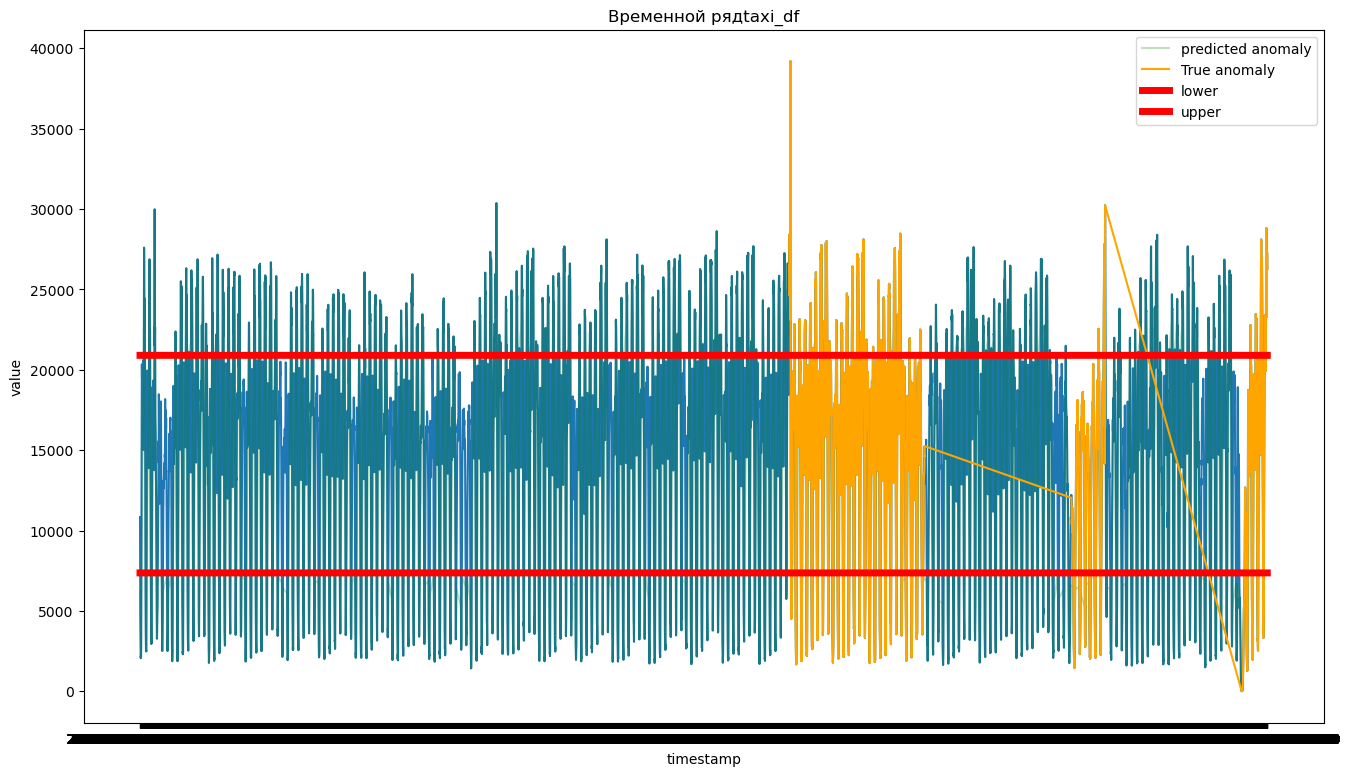

--------------------------------------------------
Количество ложноположительных срабатываний на тренировочной выборке 2378, что составляет 40.02% от всей тренировочной выборки
--------------------------------------------------
Precision на тестовой выборке составил 0.41429369067560023
--------------------------------------------------
Recall на тестовой выборке составил 0.40859030837004406
--------------------------------------------------
f1_score на тестовой выборке составил 0.41
--------------------------------------------------
f05_score на тестовой выборке составил 0.41314031180400895


In [58]:
research_df.loc[0] = static_method(taxi_df)

По графику видно, что прокрашеные значения распределены равномерно по всему рассматриваемому промежутку времени

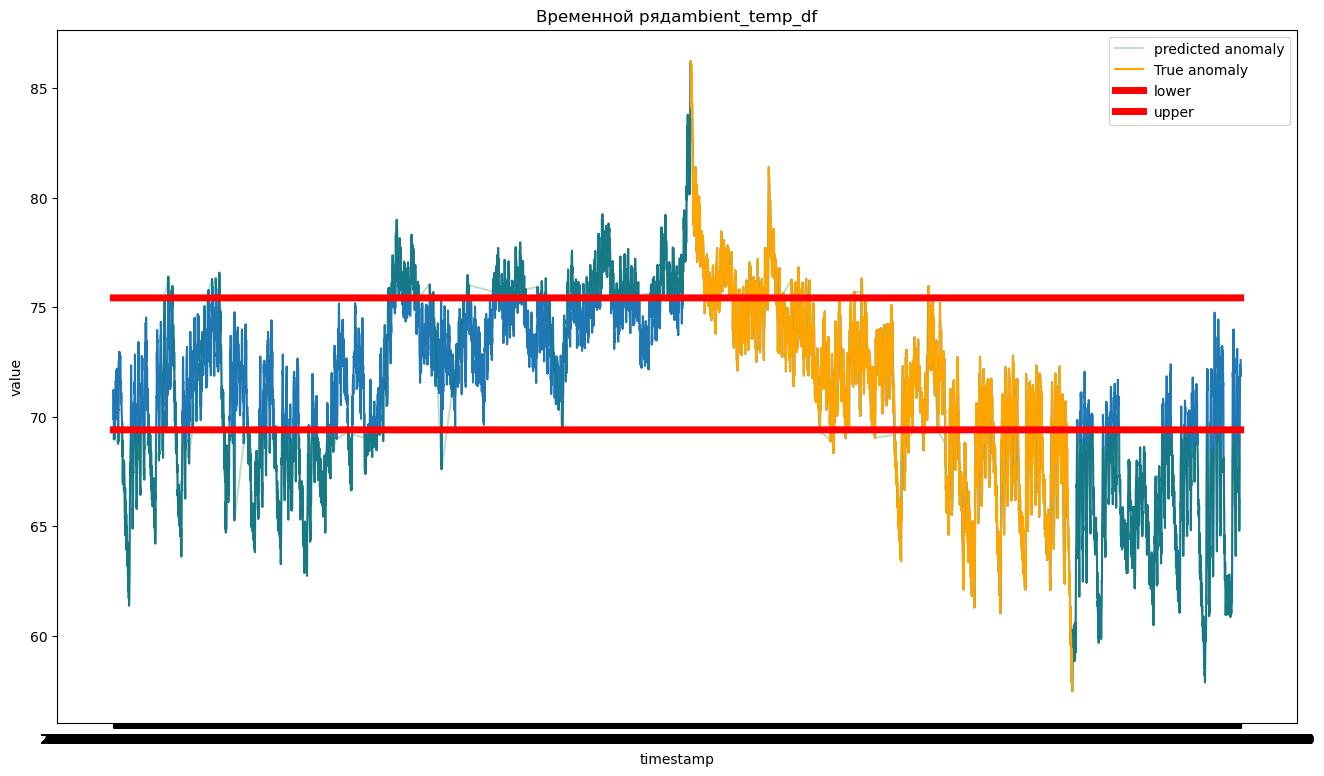

--------------------------------------------------
Количество ложноположительных срабатываний на тренировочной выборке 1490, что составляет 40.04% от всей тренировочной выборки
--------------------------------------------------
Precision на тестовой выборке составил 0.4304878048780488
--------------------------------------------------
Recall на тестовой выборке составил 0.5544502617801047
--------------------------------------------------
f1_score на тестовой выборке составил 0.48
--------------------------------------------------
f05_score на тестовой выборке составил 0.4506382978723404


In [59]:
research_df.loc[1] = static_method(ambient_temp_df, name_df = 'ambient_temp_df')

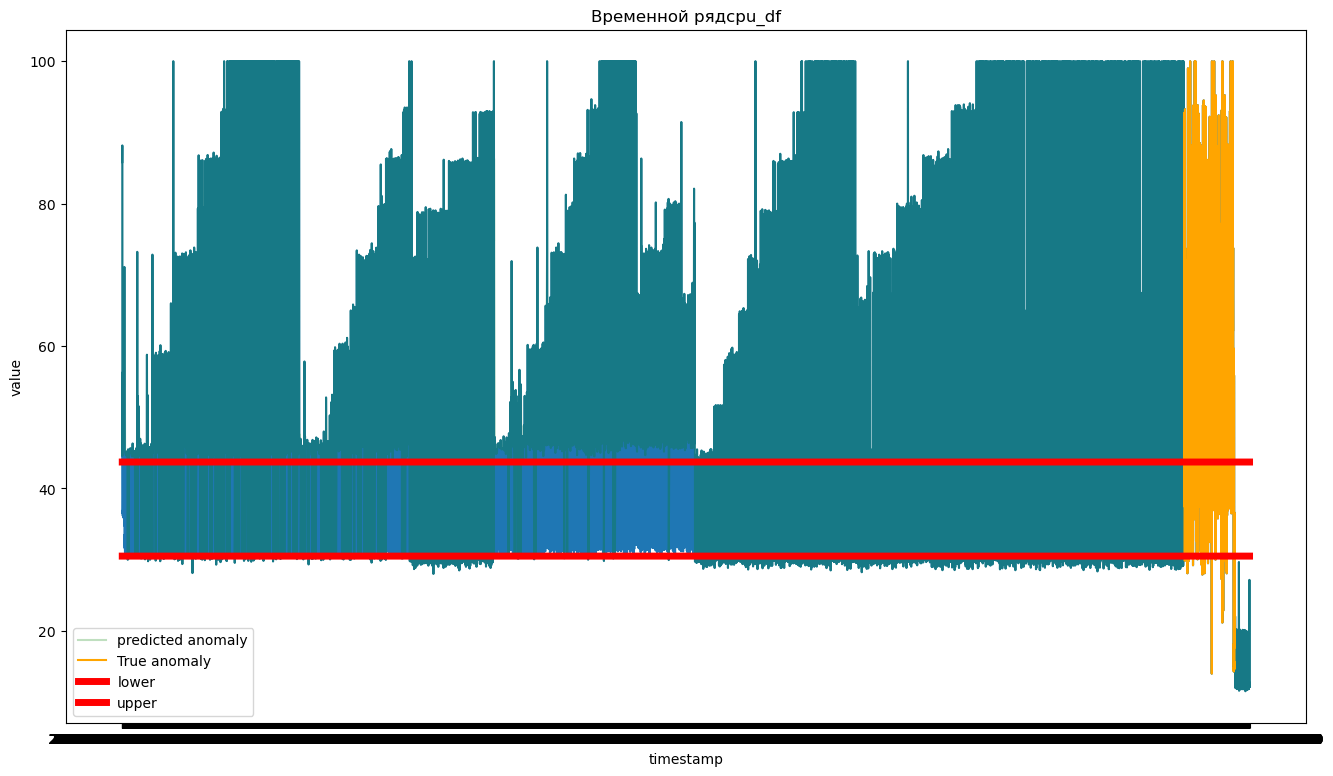

--------------------------------------------------
Количество ложноположительных срабатываний на тренировочной выборке 6804, что составляет 40.02% от всей тренировочной выборки
--------------------------------------------------
Precision на тестовой выборке составил 0.8622386223862238
--------------------------------------------------
Recall на тестовой выборке составил 0.7489316239316239
--------------------------------------------------
f1_score на тестовой выборке составил 0.8
--------------------------------------------------
f05_score на тестовой выборке составил 0.8369149952244508


In [60]:
research_df.loc[2] = static_method(cpu_df, name_df = 'cpu_df')

По результатам эксперимента метод статического порога продемонстрировал неоднозначные результаты. Несмотря на сравнительно приемлемые значения метрик на отдельных наборах данных, данный подход сопровождается крайне высоким числом ложноположительных срабатываний уже на обучающем сегменте: около 40% наблюдений тренировочной выборки были отнесены к аномальным. Это указывает на низкую селективность метода и на то, что фиксированные границы плохо согласуются с реальной структурой временного ряда.

На наборах данных nyc_taxi и ambient_temperature_system_failure значения precision, recall и F1-score находятся в диапазоне 0.41–0.48, что свидетельствует лишь о среднем качестве классификации. Более высокий результат на наборе cpu_utilization_asg_misconfiguration (F1-score = 0.80) показывает, что статический порог может быть эффективен в частных случаях, когда аномалии выражены достаточно резко относительно основного диапазона значений. Однако в общем случае данный метод оказывается недостаточно устойчивым и плохо переносится между различными временными рядами.

Таким образом, статический порог целесообразно рассматривать как наивный baseline-подход. Его основное ограничение состоит в отсутствии адаптации к изменчивости данных, сезонности и особенностям распределения значений, что приводит к значительному числу ложных срабатываний и ограничивает практическую применимость метода.

### Z_score

В качестве одного из базовых методов обнаружения аномалий использован статистический критерий z-score. На обучающем сегменте временного ряда рассчитывались среднее значение и стандартное отклонение, характеризующие нормальный режим функционирования системы. Для каждого наблюдения тестовой выборки вычислялось нормированное отклонение от среднего значения. Наблюдения, для которых абсолютное значение z-score превышало установленный порог, классифицировались как аномальные.

In [97]:
def zscore_method(df: pd.DataFrame, threshold: int = 2.0, name_df:str = 'taxi_df'):
    X_train, y_train, X_test, y_test = train_test_timeseries_split(df, train_size=0.8)
    train_mean = X_train.value.mean()
    train_std = X_train.value.std()

    X_train['z_score'] = (X_train.value - train_mean) / train_std
    X_test['z_score'] = (X_test.value - train_mean) / train_std

    X_train['predicted'] = np.where(X_train['z_score'].abs() >= threshold, 1, 0)
    X_test['predicted'] = np.where(X_test['z_score'].abs() >= threshold, 1, 0)
    metric = summary_const(df, X_train, X_test, y_train, y_test)

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)

    fig.suptitle(name_df, fontsize=16)
    
    
    
    axes[0].set_title('Результат z-score метода')
    
    # train
    sns.lineplot(
        data=X_train,
        x='timestamp',
        y='value',
        ax=axes[0],
        color='lightblue',
        label='Train'
    )
    
    # test
    sns.lineplot(
        data=X_test,
        x='timestamp',
        y='value',
        ax=axes[0],
        color='gray',
        label='Test'
    )
    
    # предсказанные аномалии на тесте
    sns.lineplot(
        data=X_test[X_test['predicted'] == 1],
        x='timestamp',
        y='value',
        ax=axes[0],
        color='red',
        label='Предсказанные аномалии'
    )
    
    axes[0].legend()
    axes[0].set_xlabel('')
    axes[0].set_ylabel('value')
    
    
    axes[1].set_title('Истинная разметка аномалий')
    
    # весь ряд как линия
    sns.lineplot(
        data=df,
        x='timestamp',
        y='value',
        ax=axes[1],
        color='lightgray',
        label='Временной ряд'
    )
    
    # реальные аномалии
    sns.lineplot(
        data=df[df['anomaly'] == 1],
        x='timestamp',
        y='value',
        ax=axes[1],
        color='red',
        label='Истинные аномалии'
    )
    
    axes[1].legend()
    axes[1].set_xlabel('timestamp')
    axes[1].set_ylabel('value')
    
    plt.tight_layout()
    plt.show()
    return {
        'dataset':name_df,
        'method':'zscore_method', 
        'threshold_type' : f'z_score',
        'params':f'threshold = {threshold}',
        **metric
    }

--------------------------------------------------
Количество ложноположительных срабатываний на тренировочной выборке 6, что составляет 0.1% от всей тренировочной выборки
--------------------------------------------------
Precision на тестовой выборке составил 0.01786711334450028
--------------------------------------------------
Recall на тестовой выборке составил 0.6808510638297872
--------------------------------------------------
f1_score на тестовой выборке составил 0.03
--------------------------------------------------
f05_score на тестовой выборке составил 0.02218832339481348


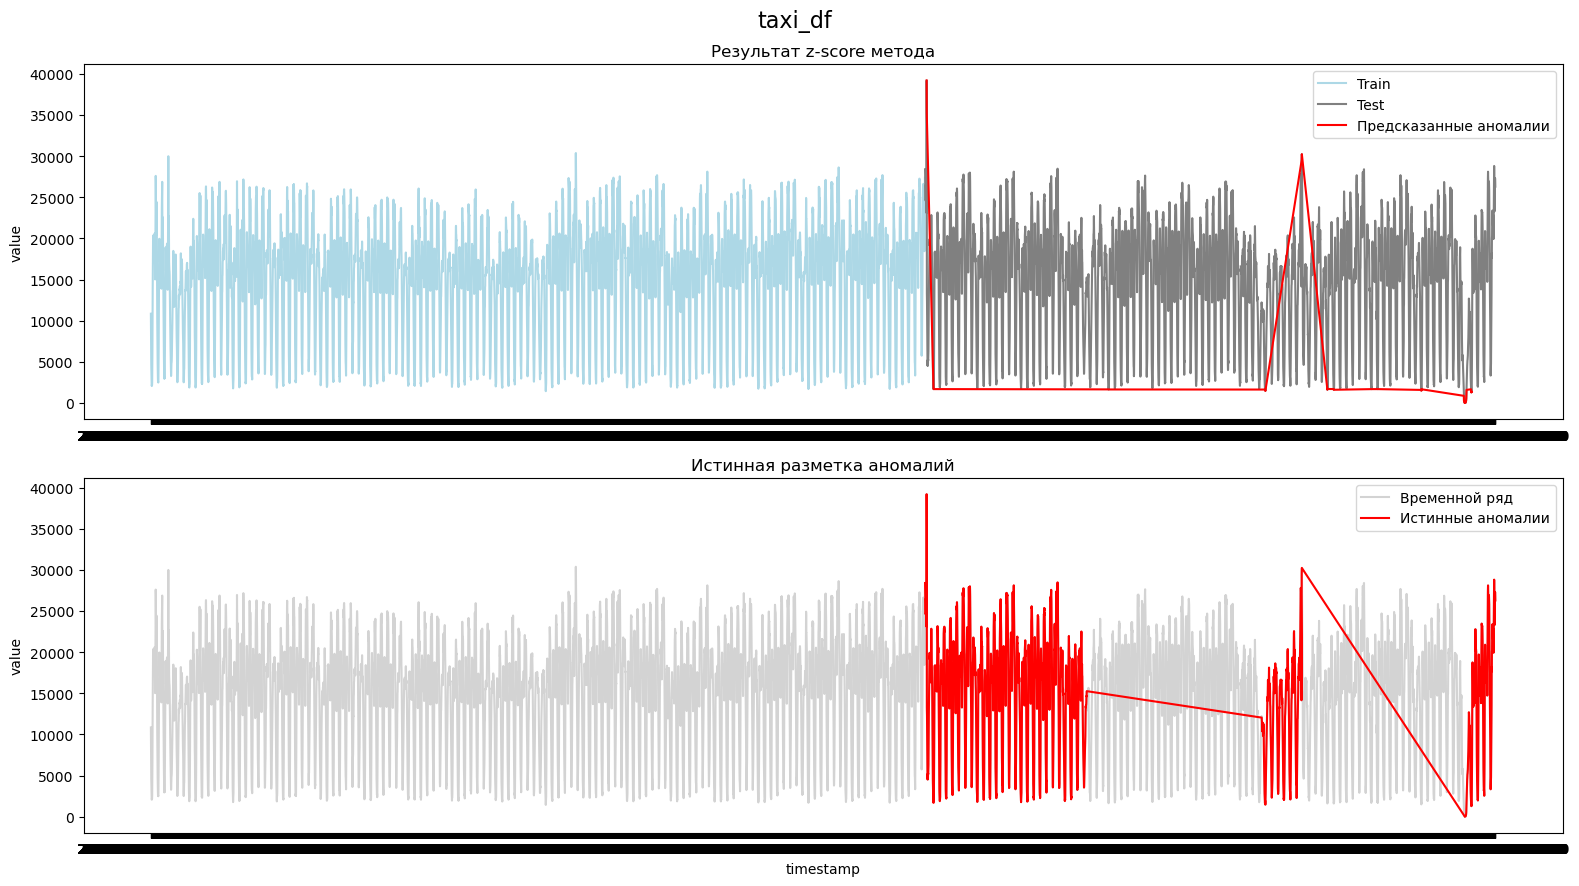

In [98]:
research_df.loc[3] = zscore_method(taxi_df)

По графику видно, что модель основаная на zscore очень плохо обнаруживает аномалии даже с достаточно лояльным threshold

--------------------------------------------------
Количество ложноположительных срабатываний на тренировочной выборке 163, что составляет 4.38% от всей тренировочной выборки
--------------------------------------------------
Precision на тестовой выборке составил 0.11463414634146342
--------------------------------------------------
Recall на тестовой выборке составил 0.373015873015873
--------------------------------------------------
f1_score на тестовой выборке составил 0.18
--------------------------------------------------
f05_score на тестовой выборке составил 0.1330690826727067


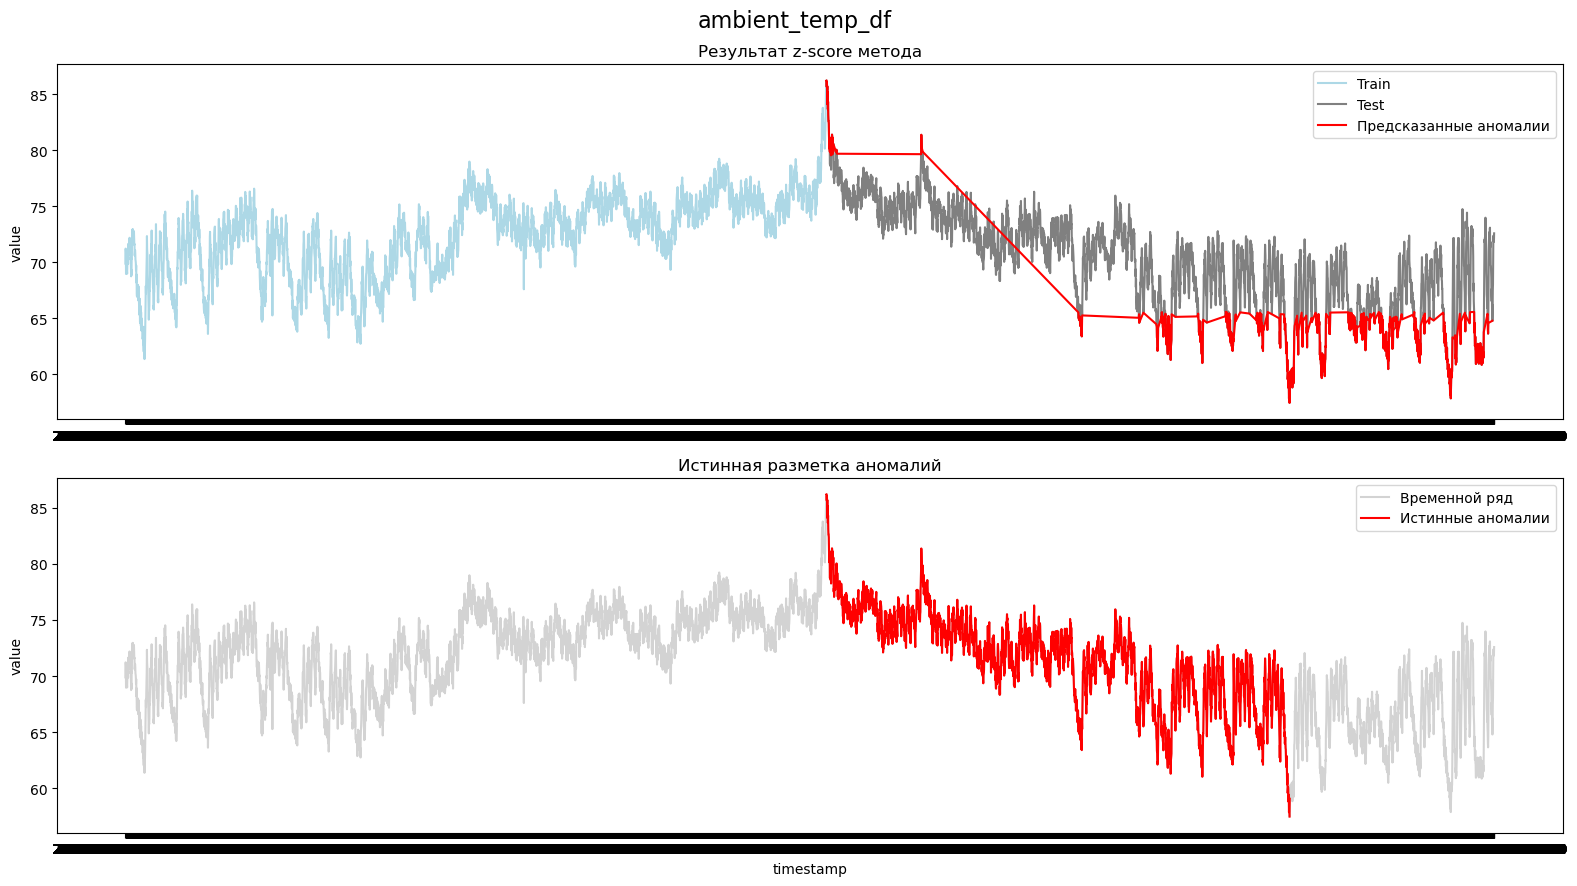

In [99]:
research_df.loc[4] = zscore_method(ambient_temp_df, name_df='ambient_temp_df')

--------------------------------------------------
Количество ложноположительных срабатываний на тренировочной выборке 1092, что составляет 6.42% от всей тренировочной выборки
--------------------------------------------------
Precision на тестовой выборке составил 0.16851168511685116
--------------------------------------------------
Recall на тестовой выборке составил 1.0
--------------------------------------------------
f1_score на тестовой выборке составил 0.29
--------------------------------------------------
f05_score на тестовой выборке составил 0.20212452050752433


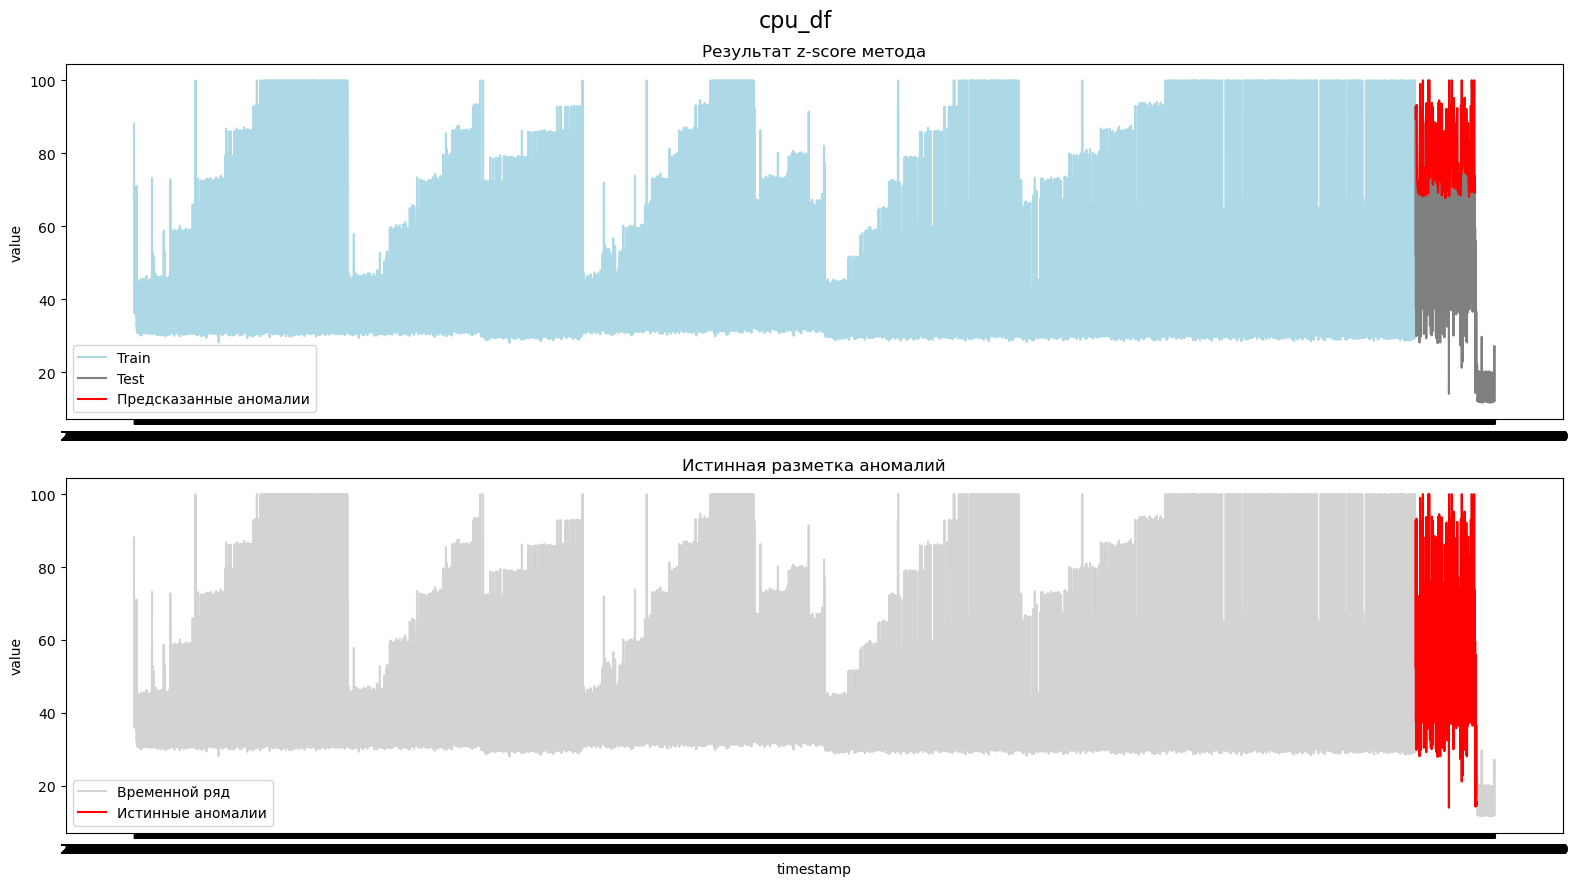

In [100]:
research_df.loc[5] = zscore_method(cpu_df, name_df = 'cpu_df')

Результаты применения метода z-score показывают, что его использование на исходном временном ряду без предварительной декомпозиции оказывается недостаточно эффективным для рассматриваемой задачи. На всех исследуемых наборах данных были получены низкие значения precision и F1-score: для nyc_taxi F1-score составил 0.03, для ambient_temperature_system_failure — 0.18, для cpu_utilization_asg_misconfiguration — 0.29. При этом значение recall в ряде случаев оказалось относительно высоким, достигая 0.68 для nyc_taxi и 1.0 для cpu_utilization_asg_misconfiguration.

Такое соотношение метрик указывает на то, что метод способен улавливать часть аномальных наблюдений, однако делает это ценой большого числа ошибок классификации. Иными словами, обнаружение аномалий сопровождается низкой точностью, что существенно снижает практическую ценность данного подхода. При этом количество ложноположительных срабатываний на обучающей выборке остаётся сравнительно небольшим, что говорит о более строгом характере метода по сравнению со статическим порогом. Однако на тестовой выборке он всё же не обеспечивает приемлемого баланса между полнотой и точностью.

Полученные результаты подтверждают, что классический z-score плохо подходит для временных рядов с выраженной сезонностью, трендом и изменяющимся уровнем ряда. Поскольку метод опирается на глобальные статистики обучающего сегмента, он не учитывает временную структуру данных и потому не способен корректно отделить реальные аномалии от нормальных колебаний ряда.

### STL + z-score

Для учета сезонной структуры временного ряда в работе использован комбинированный baseline STL + z-score. На первом этапе ряд декомпозируется методом STL на трендовую, сезонную и остаточную компоненты. На втором этапе критерий z-score применяется к остаткам ряда. Наблюдения, для которых абсолютное значение нормированного отклонения превышает установленный порог, классифицируются как аномальные. Такой подход позволяет существенно снизить влияние сезонных колебаний и тренда на результат обнаружения аномалий.

Для метода STL + z-score декомпозиция временного ряда выполнялась на полном анализируемом интервале, что позволяло корректно выделить трендовую, сезонную и остаточную компоненты. При этом параметры статистического критерия z-score, а именно среднее значение и стандартное отклонение остатков, рассчитывались только на обучающем сегменте ряда. Детектирование аномалий и оценка качества метода выполнялись исключительно на тестовом сегменте. Такой подход позволяет избежать утечки информации при оценке порога аномальности и одновременно сохранить корректность декомпозиции сезонной структуры ряда.

In [93]:
def stl_zscore(df:pd.DataFrame, threshold:int = 2.0, name_df:str = 'taxi_df'):
    params = dict(taxi_df = 48, ambient_temp_df = 24, cpu_df = 12)

    stl = STL(df["value"], period=params[name_df], robust = True)
    result = stl.fit()
    df["trend"] = result.trend
    df["seasonal"] = result.seasonal
    df["resid"] = result.resid

    X_train, y_train, X_test, y_test = train_test_timeseries_split(df, train_size=0.8)

    resid_mean = X_train.resid.mean()
    resid_std = X_train.resid.std()

    #resid_mean = df.resid.mean()
    #resid_std = df.resid.std()

    X_train['resid_zscore'] = (X_train.resid - resid_mean) / resid_std
    X_test['resid_zscore'] = (X_test.resid - resid_mean) / resid_std
    
    X_train['predicted'] = np.where(X_train['resid_zscore'].abs() >= threshold, 1, 0)
    X_test['predicted'] = np.where(X_test['resid_zscore'].abs() >= threshold, 1, 0)
    metric = summary_const(df, X_train, X_test, y_train, y_test)

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)

    fig.suptitle(name_df, fontsize=16)
    
    
    
    axes[0].set_title('Результат z-score метода')
    
    # train
    sns.lineplot(
        data=X_train,
        x='timestamp',
        y='value',
        ax=axes[0],
        color='lightblue',
        label='Train'
    )
    
    # test
    sns.lineplot(
        data=X_test,
        x='timestamp',
        y='value',
        ax=axes[0],
        color='gray',
        label='Test'
    )
    
    # предсказанные аномалии на тесте
    sns.lineplot(
        data=X_test[X_test['predicted'] == 1],
        x='timestamp',
        y='value',
        ax=axes[0],
        color='red',
        label='Предсказанные аномалии'
    )
    
    axes[0].legend()
    axes[0].set_xlabel('')
    axes[0].set_ylabel('value')
    
    
    axes[1].set_title('Истинная разметка аномалий')
    
    # весь ряд как линия
    sns.lineplot(
        data=df,
        x='timestamp',
        y='value',
        ax=axes[1],
        color='lightgray',
        label='Временной ряд'
    )
    
    # реальные аномалии
    sns.lineplot(
        data=df[df['anomaly'] == 1],
        x='timestamp',
        y='value',
        ax=axes[1],
        color='red',
        label='Истинные аномалии'
    )
    
    axes[1].legend()
    axes[1].set_xlabel('timestamp')
    axes[1].set_ylabel('value')
    
    plt.tight_layout()
    plt.show()

    return {
        'dataset':name_df,
        'method':'stl_zscore', 
        'threshold_type' : f'stl_zscore',
        'params':f'threshold = {threshold}',
        **metric
    }

--------------------------------------------------
Количество ложноположительных срабатываний на тренировочной выборке 491, что составляет 8.26% от всей тренировочной выборки
--------------------------------------------------
Precision на тестовой выборке составил 0.0943606923506421
--------------------------------------------------
Recall на тестовой выборке составил 0.41935483870967744
--------------------------------------------------
f1_score на тестовой выборке составил 0.15
--------------------------------------------------
f05_score на тестовой выборке составил 0.11166908946742433


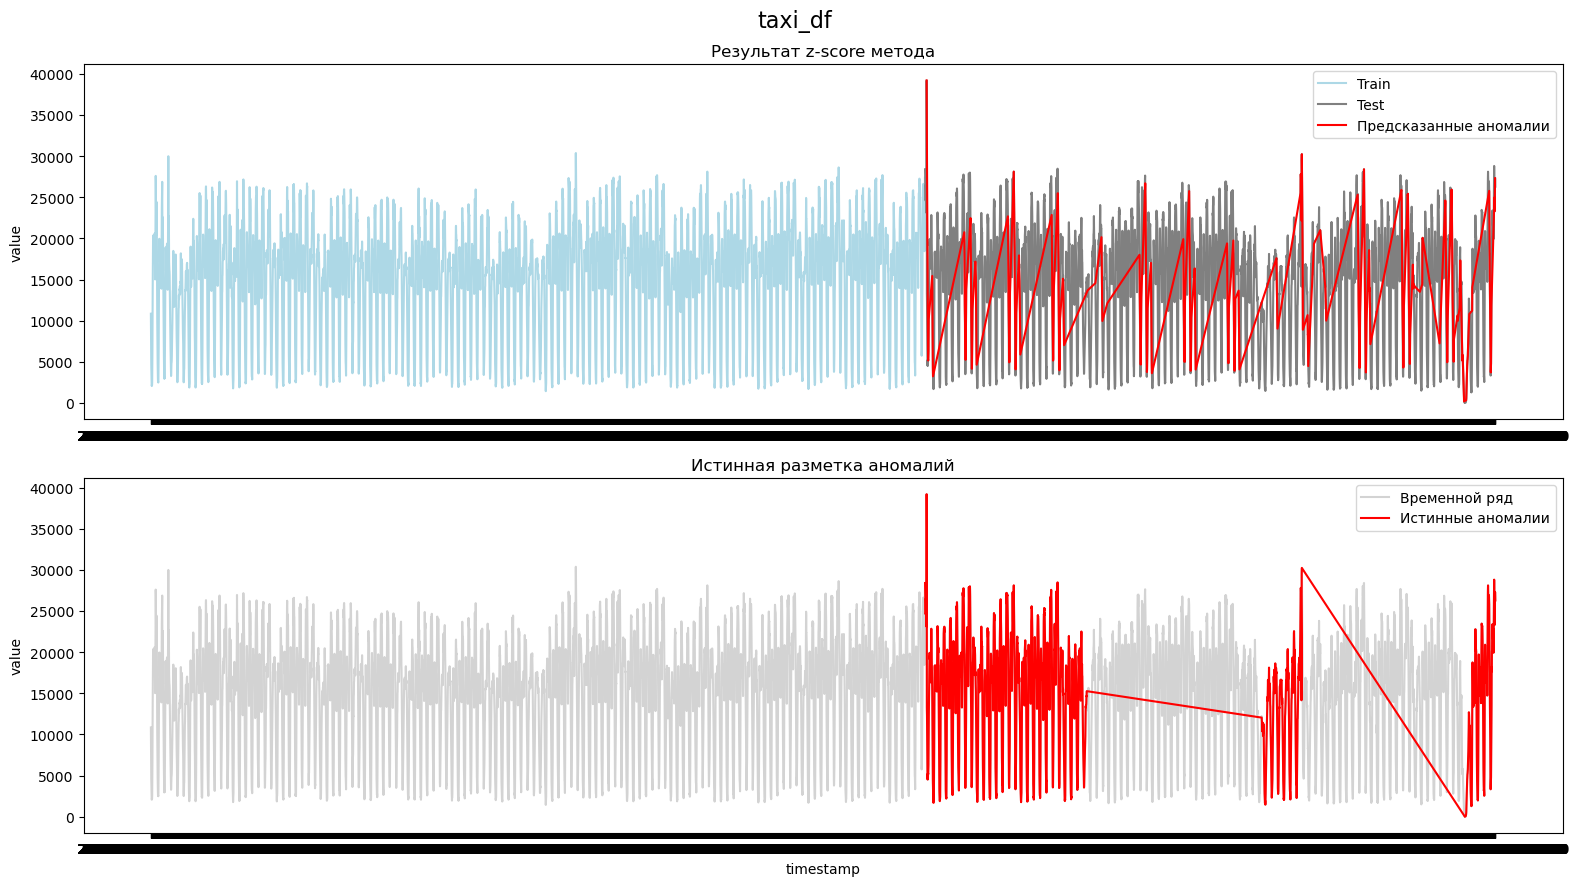

In [94]:
research_df.loc[6] = stl_zscore(taxi_df)

--------------------------------------------------
Количество ложноположительных срабатываний на тренировочной выборке 191, что составляет 5.13% от всей тренировочной выборки
--------------------------------------------------
Precision на тестовой выборке составил 0.06056910569105691
--------------------------------------------------
Recall на тестовой выборке составил 0.45426829268292684
--------------------------------------------------
f1_score на тестовой выборке составил 0.11
--------------------------------------------------
f05_score на тестовой выборке составил 0.0732690794649882


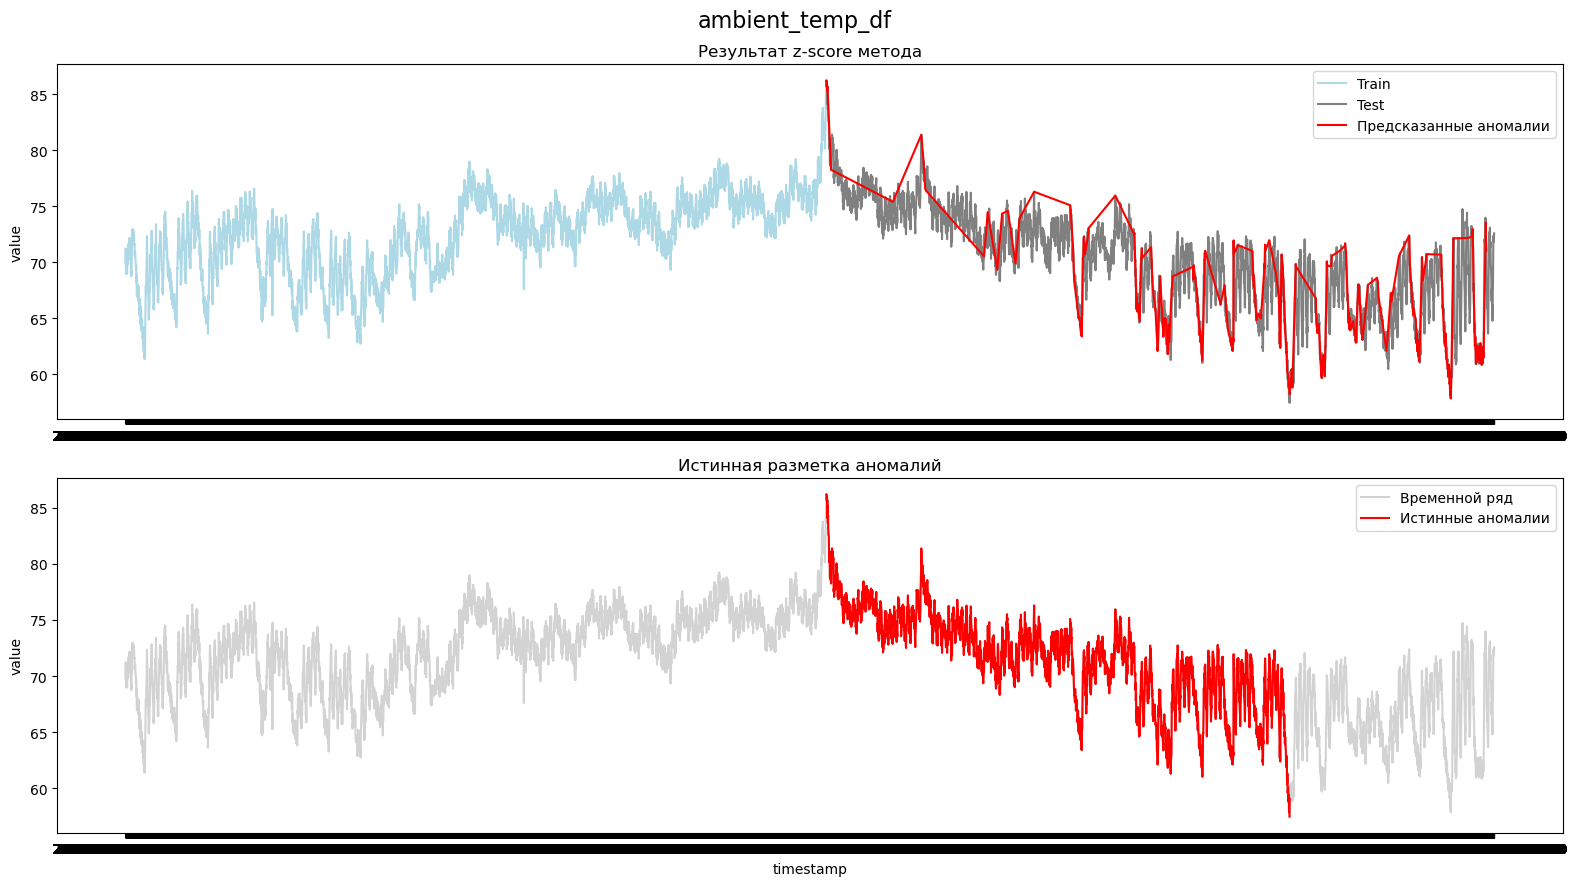

In [95]:
research_df.loc[7] = stl_zscore(df=ambient_temp_df, name_df='ambient_temp_df')

--------------------------------------------------
Количество ложноположительных срабатываний на тренировочной выборке 388, что составляет 2.28% от всей тренировочной выборки
--------------------------------------------------
Precision на тестовой выборке составил 0.32226322263222634
--------------------------------------------------
Recall на тестовой выборке составил 0.9961977186311787
--------------------------------------------------
f1_score на тестовой выборке составил 0.49
--------------------------------------------------
f05_score на тестовой выборке составил 0.37268847795163584


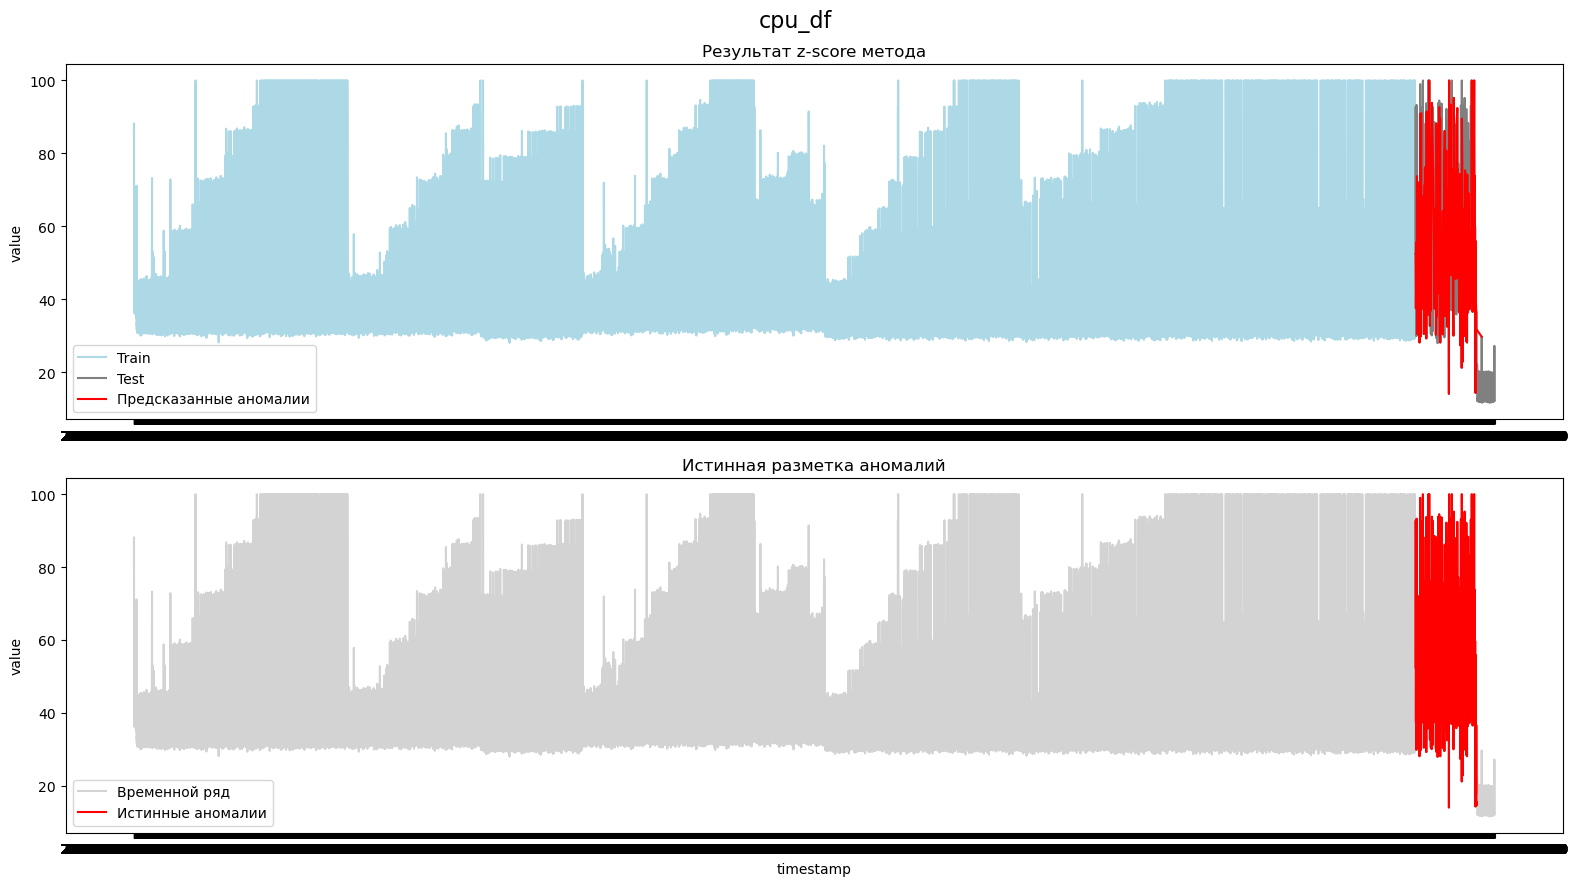

In [96]:
research_df.loc[8] = stl_zscore(df = cpu_df, name_df = 'cpu_df')

Комбинированный подход STL + z-score был использован для учета сезонной структуры временного ряда и, как ожидалось, должен был продемонстрировать более устойчивые результаты по сравнению с обычным z-score. Однако полученные результаты показывают, что даже после удаления трендовой и сезонной компонент качество классификации остаётся ограниченным. На наборах nyc_taxi и ambient_temperature_system_failure были получены низкие значения precision и F1-score: соответственно 0.09 и 0.15 для nyc_taxi, 0.05 и 0.08 для ambient_temperature_system_failure. Наиболее сильный результат был достигнут на наборе cpu_utilization_asg_misconfiguration, где F1-score составил 0.45 при recall = 1.0.

Снижение доли ложноположительных срабатываний на обучающей выборке по сравнению со статическим порогом свидетельствует о том, что предварительная декомпозиция действительно позволяет лучше отделить нормальные сезонные колебания от остаточных отклонений. Тем не менее итоговая точность на тестовых данных остаётся низкой, что говорит о недостаточной способности метода корректно выделять аномалии только на основе z-score, даже после STL-преобразования.

Следовательно, STL + z-score можно рассматривать как более содержательный статистический baseline по сравнению с двумя предыдущими методами, поскольку он учитывает сезонность и демонстрирует лучшие результаты на отдельных рядах. Однако общий уровень качества остаётся недостаточным для надёжного практического применения. Это позволяет сделать вывод о необходимости более гибких методов автоматической выработки порога, способных точнее адаптироваться к свойствам остаточной компоненты временного ряда.

Сравнение трёх базовых подходов показывает, что ни один из них не обеспечивает стабильно высокого качества на всех исследуемых временных рядах. Статический порог характеризуется чрезмерным количеством ложноположительных срабатываний, z-score на исходном ряду не учитывает временную структуру данных, а STL + z-score, несмотря на учёт сезонности, также демонстрирует ограниченную точность. Наиболее устойчивым из рассмотренных статистических baseline можно считать STL + z-score, однако и он не решает задачу в полной мере.

Тем самым результаты эксперимента подтверждают, что задача автоматического определения порогов аномальности для сезонных временных рядов требует более адаптивных подходов, способных учитывать не только средние характеристики ряда, но и особенности распределения остаточных отклонений.

In [74]:
research_df['train_fp_rate'] = research_df['train_fp_rate'] / 100

In [78]:
research_df.to_csv('baseline.csv', index = False)